# SHAP Analysis — Stacking Base Models

Notebook này visualize SHAP values cho **6 base models** trong stacking pipeline:
- **Revenue residual:** XGBoost · LightGBM · CatBoost
- **COGS Ratio:** XGBoost · LightGBM · CatBoost

**Approach 1**: SHAP trực tiếp trên từng base model với feature gốc → ý nghĩa business rõ nhất.

In [27]:
# ── Cài đặt thư viện ──────────────────────────────────────────────────────────
!pip install shap -q

In [28]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from prophet import Prophet
import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Kaggle path — chỉnh nếu cần
DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

print(f"SHAP version: {shap.__version__}")
print("Imports OK.")

SHAP version: 0.50.0
Imports OK.


## 1. Helper Functions (copy từ pipeline chính)

In [29]:
SALE_SEASONS = [
    {'month': 1,  'start_day': 30, 'duration': 30, 'profit_rank': 1},
    {'month': 3,  'start_day': 18, 'duration': 30, 'profit_rank': 2},
    {'month': 6,  'start_day': 23, 'duration': 29, 'profit_rank': 3},
    {'month': 7,  'start_day': 30, 'duration': 34, 'profit_rank': 5},
    {'month': 8,  'start_day': 30, 'duration': 32, 'profit_rank': 4},
    {'month': 11, 'start_day': 18, 'duration': 45, 'profit_rank': 6},
]

def add_seasonality_features(df):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df['year']      = df['Date'].dt.year
    df['month']     = df['Date'].dt.month
    df['day']       = df['Date'].dt.day
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['is_peak_season'] = df['Date'].dt.month.isin([4, 5, 11]).astype(int)

    def days_to_nearest_peak(date):
        year = date.year
        candidates = [
            pd.Timestamp(year,     4,  1), pd.Timestamp(year,     5,  1), pd.Timestamp(year,    11,  1),
            pd.Timestamp(year - 1, 4,  1), pd.Timestamp(year - 1, 5,  1), pd.Timestamp(year - 1, 11, 1),
            pd.Timestamp(year + 1, 4,  1), pd.Timestamp(year + 1, 5,  1), pd.Timestamp(year + 1, 11, 1),
        ]
        return min(abs((date - c).days) for c in candidates)

    days_to_peak = df['Date'].map(days_to_nearest_peak)
    df['peak_proximity'] = 1 / (1 + days_to_peak)
    month = df['Date'].dt.month
    df['month_sin'] = np.sin(2 * np.pi * month / 12)
    df['month_cos'] = np.cos(2 * np.pi * month / 12)
    return df

def _get_sale_windows(years):
    windows = []
    for year in years:
        for s in SALE_SEASONS:
            try:
                start = pd.Timestamp(year=year, month=s['month'], day=s['start_day'])
            except ValueError:
                start = pd.Timestamp(year=year, month=s['month'], day=1) + pd.offsets.MonthEnd(0)
            end = start + pd.Timedelta(days=s['duration'] - 1)
            windows.append((start, end, s['profit_rank']))
    return windows

def add_sale_features(df):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    years   = df['Date'].dt.year.unique()
    windows = _get_sale_windows(years)
    df['is_sale_season']       = 0
    df['sale_rank']            = 0
    df['sale_progress']        = 0.0
    df['days_to_next_sale']    = 999
    df['days_since_last_sale'] = 999

    for start, end, rank in windows:
        mask_in     = (df['Date'] >= start) & (df['Date'] <= end)
        mask_before = df['Date'] < start
        mask_after  = df['Date'] > end
        df.loc[mask_in, 'is_sale_season'] = 1
        df.loc[mask_in, 'sale_rank']      = rank
        days_to = (start - df.loc[mask_before, 'Date']).dt.days
        df.loc[mask_before, 'days_to_next_sale'] = np.minimum(
            df.loc[mask_before, 'days_to_next_sale'], days_to)
        days_since = (df.loc[mask_after, 'Date'] - end).dt.days
        df.loc[mask_after, 'days_since_last_sale'] = np.minimum(
            df.loc[mask_after, 'days_since_last_sale'], days_since)

    df.loc[df['is_sale_season'] == 1, 'days_to_next_sale']    = 0
    df.loc[df['is_sale_season'] == 1, 'days_since_last_sale'] = 0
    return df

def add_features(df):
    df = df.copy()
    df = add_seasonality_features(df)
    df = add_sale_features(df)
    return df

STATIC_FEATURES = [
    'year', 'month', 'day', 'dayofweek',
    'month_sin', 'month_cos', 'is_peak_season', 'peak_proximity',
    'is_sale_season', 'sale_rank', 'days_to_next_sale', 'days_since_last_sale'
]

print(f"Features ({len(STATIC_FEATURES)}): {STATIC_FEATURES}")

Features (12): ['year', 'month', 'day', 'dayofweek', 'month_sin', 'month_cos', 'is_peak_season', 'peak_proximity', 'is_sale_season', 'sale_rank', 'days_to_next_sale', 'days_since_last_sale']


## 2. Load Data & Build Targets

In [30]:
df = pd.read_csv(DIR + "sales.csv")
df['Revenue_log'] = np.log1p(df['Revenue'])
df['COGS_Ratio']  = df['COGS'] / (df['Revenue'] + 1e-9)
df = add_features(df)

print(f"Train rows: {len(df):,}  |  Date range: {df['Date'].min()} → {df['Date'].max()}")
print(f"Revenue range: {df['Revenue'].min():,.0f} – {df['Revenue'].max():,.0f}")
df[STATIC_FEATURES].describe()

Train rows: 3,833  |  Date range: 2012-07-04 00:00:00 → 2022-12-31 00:00:00
Revenue range: 279,814 – 20,905,271


,year,month,day,dayofweek,month_sin,month_cos,is_peak_season,peak_proximity,is_sale_season,sale_rank,days_to_next_sale,days_since_last_sale
count,3833.000000,3833.000000,3833.000000,3833.000000,3.833000e+03,3.833000e+03,3833.000000,3833.000000,3833.000000,3833.000000,3833.000000,3833.000000
mean,2017.240543,6.665797,15.743804,3.000522,-3.407319e-02,6.541038e-03,0.245239,0.064355,0.546569,2.061310,10.889121,10.889121
std,3.036754,3.446462,8.798166,1.999608,7.051758e-01,7.083671e-01,0.430285,0.118006,0.497892,2.280362,16.840433,16.840433
min,2012.000000,1.000000,1.000000,0.000000,-1.000000e+00,-1.000000e+00,0.000000,0.010753,0.000000,0.000000,0.000000,0.000000
25%,2015.000000,4.000000,8.000000,1.000000,-8.660254e-01,-5.000000e-01,0.000000,0.016129,0.000000,0.000000,0.000000,0.000000
50%,2017.000000,7.000000,16.000000,3.000000,-2.449294e-16,-1.836970e-16,0.000000,0.025641,1.000000,1.000000,0.000000,0.000000
75%,2020.000000,10.000000,23.000000,5.000000,5.000000e-01,8.660254e-01,0.000000,0.058824,1.000000,4.000000,17.000000,17.000000
max,2022.000000,12.000000,31.000000,6.000000,1.000000e+00,1.000000e+00,1.000000,1.000000,1.000000,6.000000,67.000000,67.000000


## 3. Train Prophet → Compute Residuals (Full Data)

In [31]:
prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
prophet_df = df[['Date', 'Revenue_log']].rename(columns={'Date': 'ds', 'Revenue_log': 'y'})
prophet.fit(prophet_df)

prophet_trend = prophet.predict(prophet_df)['yhat'].values
df['residual'] = df['Revenue_log'] - prophet_trend

print(f"Residual stats: mean={df['residual'].mean():.4f}, std={df['residual'].std():.4f}")
print(f"COGS_Ratio stats: mean={df['COGS_Ratio'].mean():.4f}, std={df['COGS_Ratio'].std():.4f}")

16:37:48 - cmdstanpy - INFO - Chain [1] start processing
16:37:49 - cmdstanpy - INFO - Chain [1] done processing


Residual stats: mean=0.0000, std=0.3723
COGS_Ratio stats: mean=0.8746, std=0.1274


## 4. Train 6 Base Models (Best Params từ Notebook Chính)

In [32]:
# ── Hyperparams (best từ Optuna — copy nguyên từ notebook pipeline) ───────────
best_xgb_params = {
    "n_estimators": 600,
    "learning_rate": 0.07687359172082428,
    "max_depth": 4,
    "objective": "reg:pseudohubererror",
    "tree_method": "hist",
    "random_state": 42,
    "subsample": 0.9640163894074474,
    "colsample_bytree": 0.9988728404218791,
    "min_child_weight": 6
}

best_lgb_params = {
    "n_estimators": 600,
    "learning_rate": 0.010074446630670307,
    "max_depth": 4,
    "objective": "huber",
    "random_state": 42,
    "verbose": -1,
    "num_leaves": 28,
    "subsample": 0.932752195699773,
    "colsample_bytree": 0.8528851999663052
}

best_cat_params = {
    "iterations": 600,
    "learning_rate": 0.09865972508027333,
    "depth": 4,
    "loss_function": "Huber:delta=1.5",
    "random_state": 42,
    "verbose": False,
    "l2_leaf_reg": 5.35578476395823
}

X = df[STATIC_FEATURES]
y_res  = df['residual']    # Revenue residual
y_rat  = df['COGS_Ratio']  # COGS ratio

print("Training 6 base models...")

# ── Revenue residual models ───────────────────────────────────────────────────
rev_xgb = xgb.XGBRegressor(**best_xgb_params)
rev_xgb.fit(X, y_res, verbose=False)
print("  [1/6] Revenue XGBoost ✓")

rev_lgb = lgb.LGBMRegressor(**best_lgb_params)
rev_lgb.fit(X, y_res)
print("  [2/6] Revenue LightGBM ✓")

rev_cat = CatBoostRegressor(**best_cat_params)
rev_cat.fit(X, y_res, verbose=False)
print("  [3/6] Revenue CatBoost ✓")

# ── COGS ratio models ─────────────────────────────────────────────────────────
rat_xgb = xgb.XGBRegressor(**best_xgb_params)
rat_xgb.fit(X, y_rat, verbose=False)
print("  [4/6] COGS Ratio XGBoost ✓")

rat_lgb = lgb.LGBMRegressor(**best_lgb_params)
rat_lgb.fit(X, y_rat)
print("  [5/6] COGS Ratio LightGBM ✓")

rat_cat = CatBoostRegressor(**best_cat_params)
rat_cat.fit(X, y_rat, verbose=False)
print("  [6/6] COGS Ratio CatBoost ✓")

print("\nAll 6 models trained.")

Training 6 base models...
  [1/6] Revenue XGBoost ✓
  [2/6] Revenue LightGBM ✓
  [3/6] Revenue CatBoost ✓
  [4/6] COGS Ratio XGBoost ✓
  [5/6] COGS Ratio LightGBM ✓
  [6/6] COGS Ratio CatBoost ✓

All 6 models trained.


## 5. Compute SHAP Values (TreeExplainer — native, nhanh)

Dùng **background sample 800 rows** để cân bằng tốc độ và độ chính xác.

In [33]:
# ── Background sample ─────────────────────────────────────────────────────────
np.random.seed(42)
bg_idx = np.random.choice(len(X), size=min(800, len(X)), replace=False)
X_bg = X.iloc[bg_idx].reset_index(drop=True)

print(f"Background sample: {len(X_bg)} rows")

# ── SHAP values dict ──────────────────────────────────────────────────────────
shap_dict = {}

models_info = [
    ('Revenue Residual', 'XGBoost',   rev_xgb, 'rev'),
    ('Revenue Residual', 'LightGBM',  rev_lgb, 'rev'),
    ('Revenue Residual', 'CatBoost',  rev_cat, 'rev'),
    ('COGS Ratio',       'XGBoost',   rat_xgb, 'rat'),
    ('COGS Ratio',       'LightGBM',  rat_lgb, 'rat'),
    ('COGS Ratio',       'CatBoost',  rat_cat, 'rat'),
]

for target, algo, model, tag in models_info:
    key = f"{tag}_{algo.lower()}"
    print(f"Computing SHAP: {target} — {algo}...", end=' ')
    explainer = shap.TreeExplainer(model)
    sv = explainer(X_bg)
    shap_dict[key] = sv
    print("✓")

print("\nSHAP computation done.")

Background sample: 800 rows
Computing SHAP: Revenue Residual — XGBoost... ✓
Computing SHAP: Revenue Residual — LightGBM... ✓
Computing SHAP: Revenue Residual — CatBoost... ✓
Computing SHAP: COGS Ratio — XGBoost... ✓
Computing SHAP: COGS Ratio — LightGBM... ✓
Computing SHAP: COGS Ratio — CatBoost... ✓

SHAP computation done.


## 6. Revenue Residual — SHAP Beeswarm (XGB · LGB · CAT)

Beeswarm cho thấy **hướng tác động** (đỏ = giá trị feature cao, xanh = thấp) và **magnitude** của từng feature lên residual của Revenue.

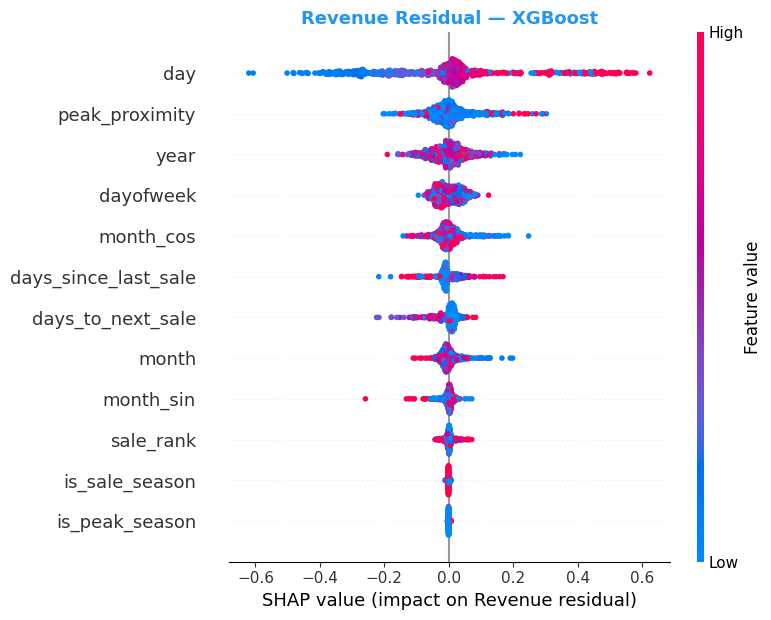

In [34]:
# 6a. Revenue Residual — XGBoost
fig, ax = plt.subplots(figsize=(9, 7))
plt.sca(ax)
shap.plots.beeswarm(shap_dict['rev_xgboost'], max_display=12, show=False)
ax.set_title("Revenue Residual — XGBoost", fontsize=13, fontweight='bold', color='#2196F3')
ax.set_xlabel("SHAP value (impact on Revenue residual)")
plt.tight_layout()
plt.savefig("shap_beeswarm_revenue_xgb.png", dpi=150, bbox_inches='tight')
plt.show()

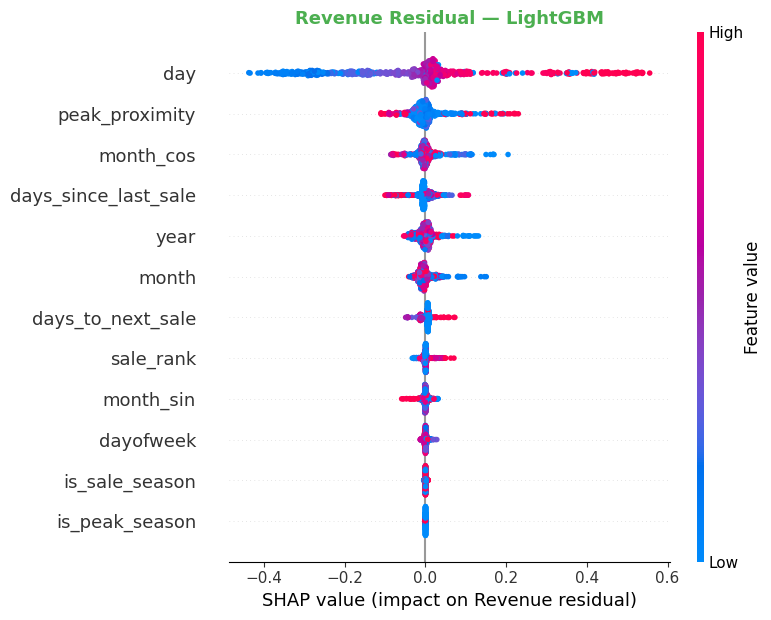

In [35]:
# 6b. Revenue Residual — LightGBM
fig, ax = plt.subplots(figsize=(9, 7))
plt.sca(ax)
shap.plots.beeswarm(shap_dict['rev_lightgbm'], max_display=12, show=False)
ax.set_title("Revenue Residual — LightGBM", fontsize=13, fontweight='bold', color='#4CAF50')
ax.set_xlabel("SHAP value (impact on Revenue residual)")
plt.tight_layout()
plt.savefig("shap_beeswarm_revenue_lgb.png", dpi=150, bbox_inches='tight')
plt.show()

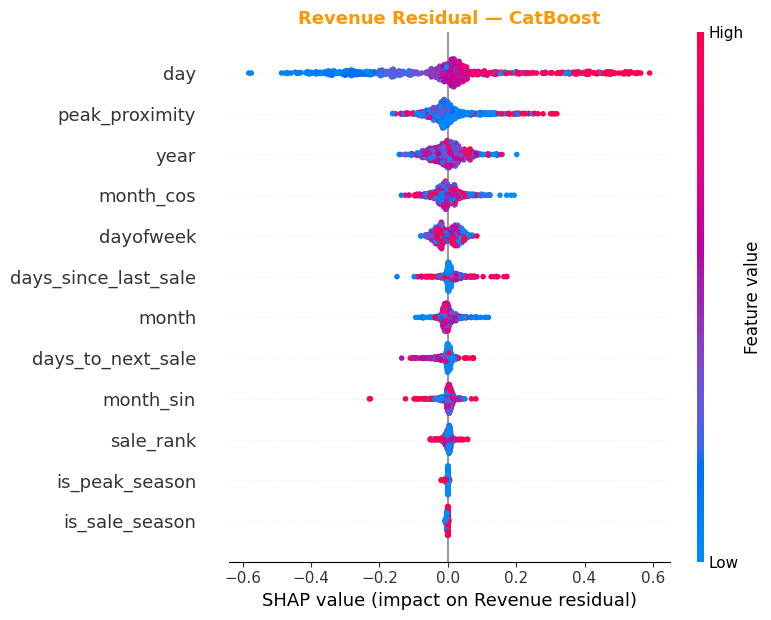

In [36]:
# 6c. Revenue Residual — CatBoost
fig, ax = plt.subplots(figsize=(9, 7))
plt.sca(ax)
shap.plots.beeswarm(shap_dict['rev_catboost'], max_display=12, show=False)
ax.set_title("Revenue Residual — CatBoost", fontsize=13, fontweight='bold', color='#FF9800')
ax.set_xlabel("SHAP value (impact on Revenue residual)")
plt.tight_layout()
plt.savefig("shap_beeswarm_revenue_cat.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. COGS Ratio — SHAP Beeswarm (XGB · LGB · CAT)

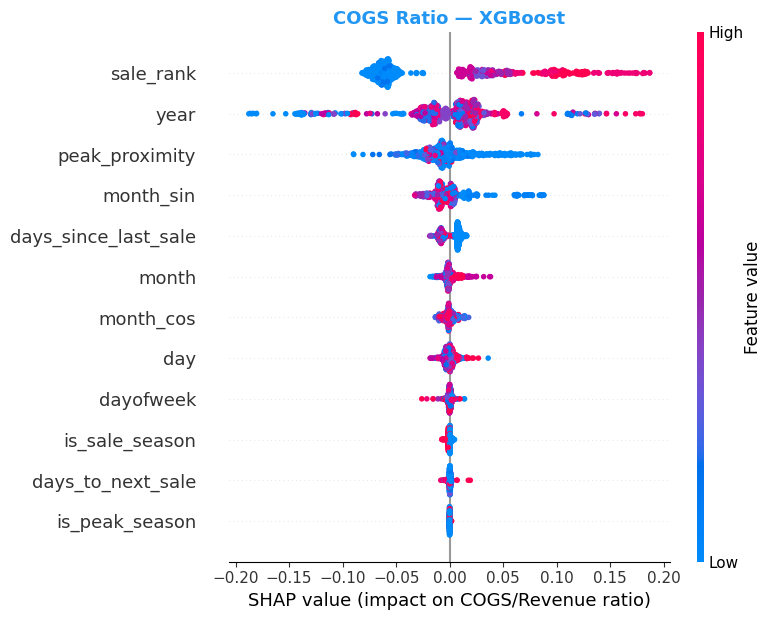

In [37]:
# 7a. COGS Ratio — XGBoost
fig, ax = plt.subplots(figsize=(9, 7))
plt.sca(ax)
shap.plots.beeswarm(shap_dict['rat_xgboost'], max_display=12, show=False)
ax.set_title("COGS Ratio — XGBoost", fontsize=13, fontweight='bold', color='#2196F3')
ax.set_xlabel("SHAP value (impact on COGS/Revenue ratio)")
plt.tight_layout()
plt.savefig("shap_beeswarm_cogs_xgb.png", dpi=150, bbox_inches='tight')
plt.show()

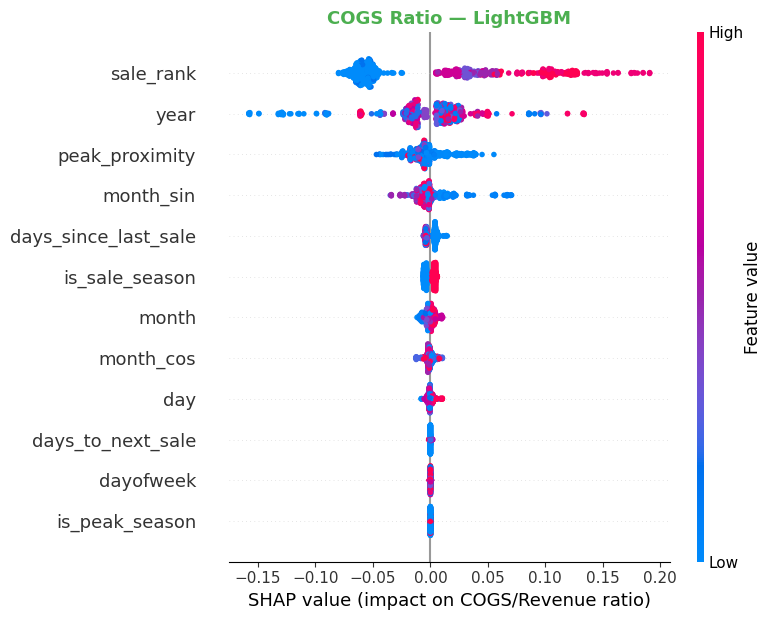

In [38]:
# 7b. COGS Ratio — LightGBM
fig, ax = plt.subplots(figsize=(9, 7))
plt.sca(ax)
shap.plots.beeswarm(shap_dict['rat_lightgbm'], max_display=12, show=False)
ax.set_title("COGS Ratio — LightGBM", fontsize=13, fontweight='bold', color='#4CAF50')
ax.set_xlabel("SHAP value (impact on COGS/Revenue ratio)")
plt.tight_layout()
plt.savefig("shap_beeswarm_cogs_lgb.png", dpi=150, bbox_inches='tight')
plt.show()

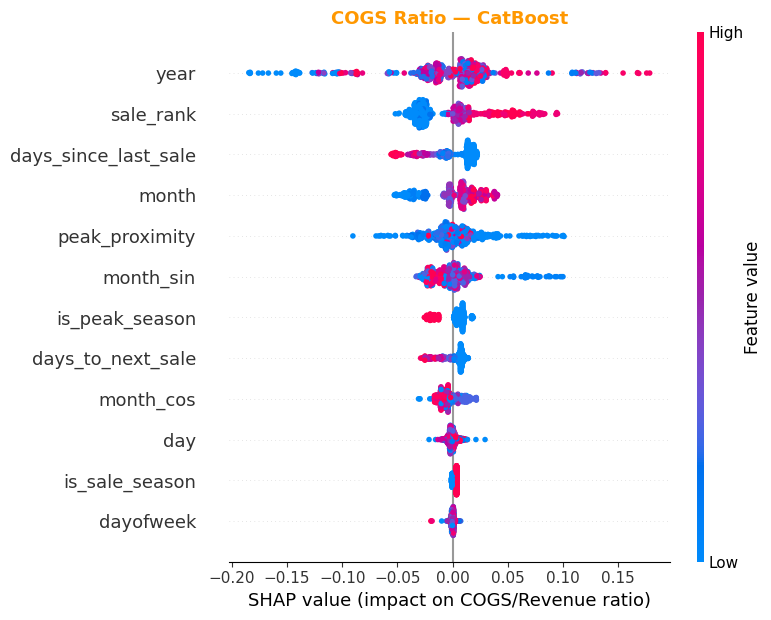

In [39]:
# 7c. COGS Ratio — CatBoost
fig, ax = plt.subplots(figsize=(9, 7))
plt.sca(ax)
shap.plots.beeswarm(shap_dict['rat_catboost'], max_display=12, show=False)
ax.set_title("COGS Ratio — CatBoost", fontsize=13, fontweight='bold', color='#FF9800')
ax.set_xlabel("SHAP value (impact on COGS/Revenue ratio)")
plt.tight_layout()
plt.savefig("shap_beeswarm_cogs_cat.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Mean |SHAP| Bar Chart — Top Features per Model

Bar chart mean absolute SHAP = **global feature importance** theo thứ tự giảm dần.

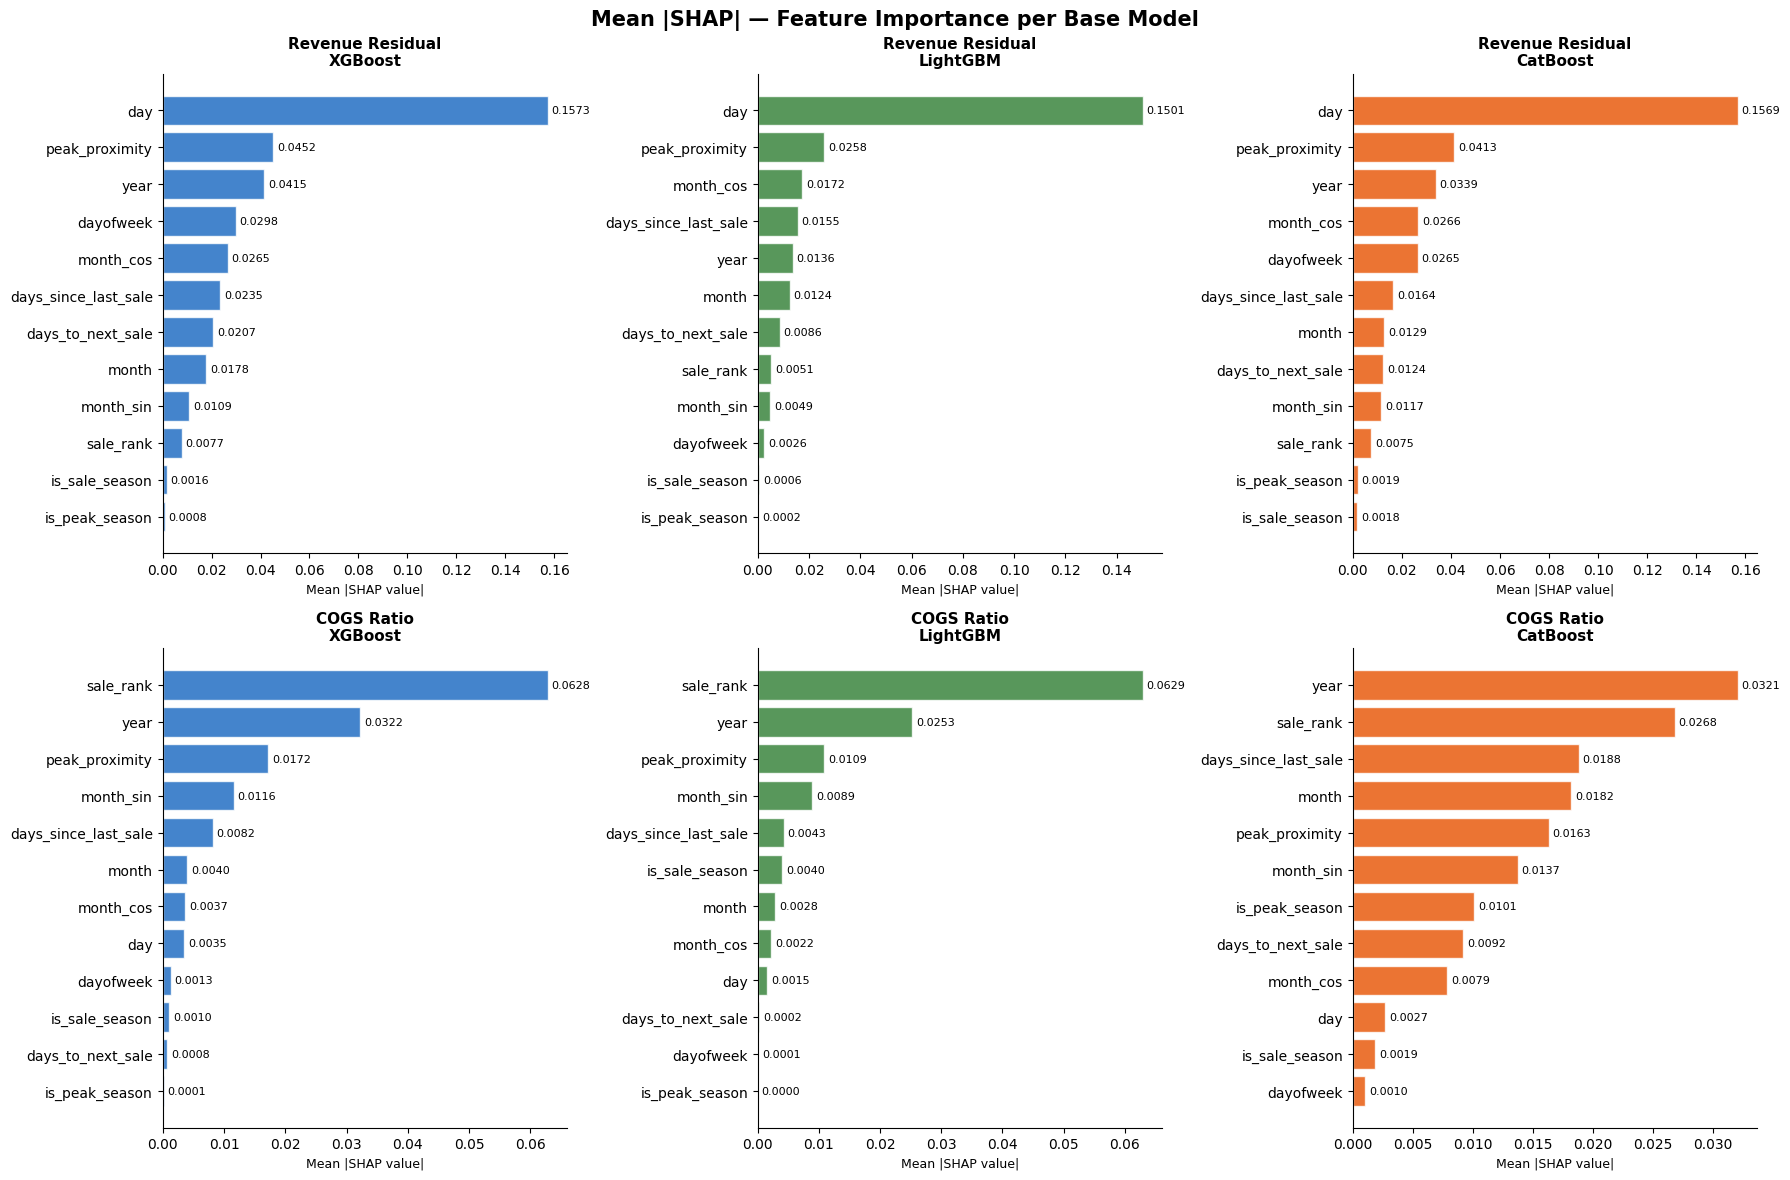

Saved: shap_bar_all_models.png


In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Mean |SHAP| — Feature Importance per Base Model", fontsize=15, fontweight='bold')

all_models = [
    ('rev_xgboost',  'Revenue Residual\nXGBoost',  '#1565C0'),
    ('rev_lightgbm', 'Revenue Residual\nLightGBM', '#2E7D32'),
    ('rev_catboost', 'Revenue Residual\nCatBoost', '#E65100'),
    ('rat_xgboost',  'COGS Ratio\nXGBoost',        '#1565C0'),
    ('rat_lightgbm', 'COGS Ratio\nLightGBM',       '#2E7D32'),
    ('rat_catboost', 'COGS Ratio\nCatBoost',       '#E65100'),
]

for ax, (key, label, color) in zip(axes.flatten(), all_models):
    sv = shap_dict[key]
    mean_abs = np.abs(sv.values).mean(axis=0)
    importance = pd.Series(mean_abs, index=STATIC_FEATURES).sort_values(ascending=True)
    
    bars = ax.barh(importance.index, importance.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel("Mean |SHAP value|", fontsize=9)
    
    # Annotate values
    for bar, val in zip(bars, importance.values):
        ax.text(val + max(importance.values) * 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("shap_bar_all_models.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar_all_models.png")

## 9. Cross-Model Consistency — Heatmap Mean |SHAP|

So sánh ranking feature importance giữa 3 Revenue models và 3 COGS Ratio models. Feature nào **consistent** across models thì đáng tin cậy nhất.

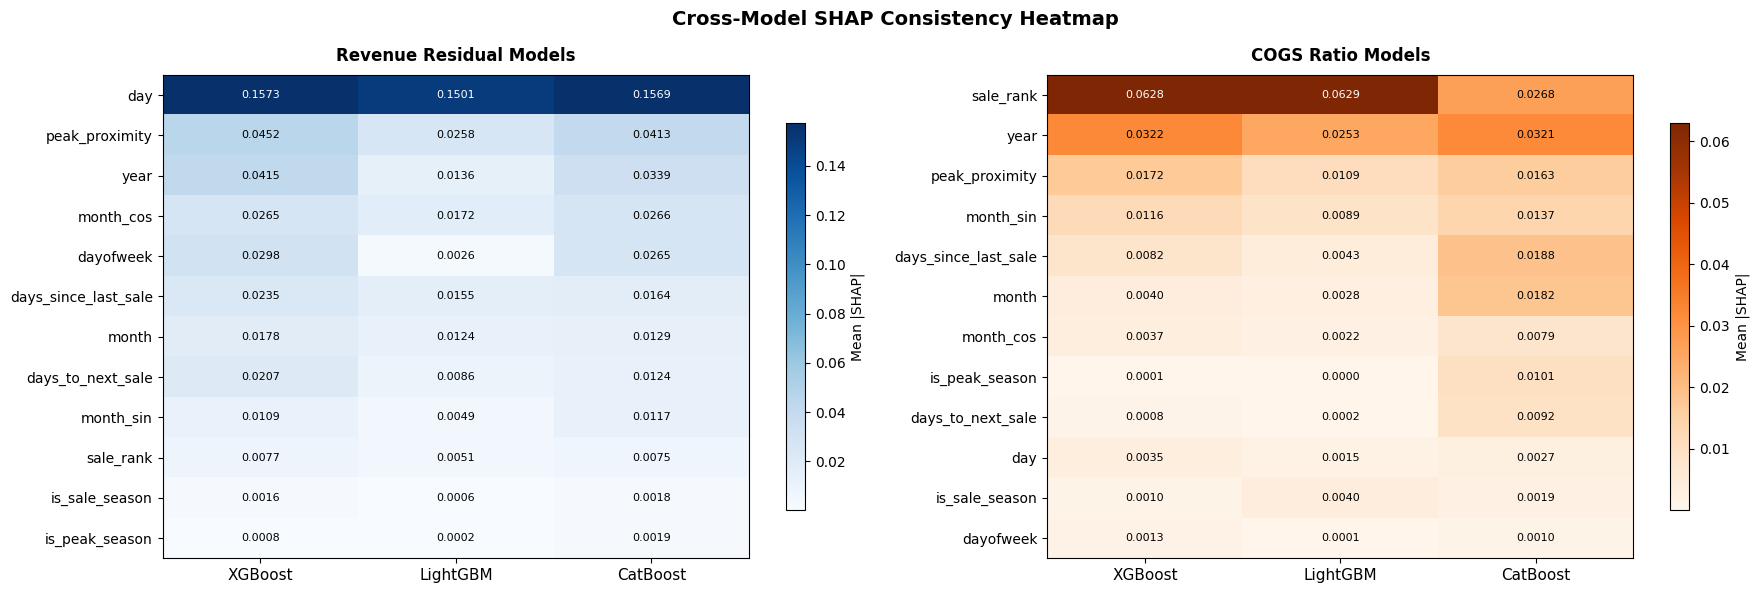

Saved: shap_heatmap_consistency.png


In [41]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Cross-Model SHAP Consistency Heatmap", fontsize=14, fontweight='bold')

def build_heatmap(ax, keys, col_labels, title, cmap='YlOrRd'):
    data = {}
    for key, col in zip(keys, col_labels):
        sv = shap_dict[key]
        mean_abs = np.abs(sv.values).mean(axis=0)
        data[col] = mean_abs
    
    heat_df = pd.DataFrame(data, index=STATIC_FEATURES)
    # Sort by mean across models
    heat_df['_mean'] = heat_df.mean(axis=1)
    heat_df = heat_df.sort_values('_mean', ascending=False).drop('_mean', axis=1)
    
    im = ax.imshow(heat_df.values, aspect='auto', cmap=cmap)
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, fontsize=11)
    ax.set_yticks(range(len(heat_df)))
    ax.set_yticklabels(heat_df.index, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    
    # Annotate cells
    for i in range(len(heat_df)):
        for j in range(len(col_labels)):
            val = heat_df.values[i, j]
            ax.text(j, i, f'{val:.4f}', ha='center', va='center',
                    fontsize=8, color='black' if val < heat_df.values.max()*0.6 else 'white')
    
    plt.colorbar(im, ax=ax, shrink=0.8, label='Mean |SHAP|')
    return heat_df

rev_heat = build_heatmap(
    axes[0],
    ['rev_xgboost', 'rev_lightgbm', 'rev_catboost'],
    ['XGBoost', 'LightGBM', 'CatBoost'],
    'Revenue Residual Models',
    cmap='Blues'
)

rat_heat = build_heatmap(
    axes[1],
    ['rat_xgboost', 'rat_lightgbm', 'rat_catboost'],
    ['XGBoost', 'LightGBM', 'CatBoost'],
    'COGS Ratio Models',
    cmap='Oranges'
)

plt.tight_layout()
plt.savefig("shap_heatmap_consistency.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_heatmap_consistency.png")

## 10. Dependence Plots — Top 2 Features theo Revenue XGBoost

Dependence plot cho thấy **mối quan hệ phi tuyến** giữa một feature và SHAP value của nó. Màu sắc = feature tương tác mạnh nhất (SHAP tự detect).

Top 2 features (Revenue XGBoost): ['day', 'peak_proximity']


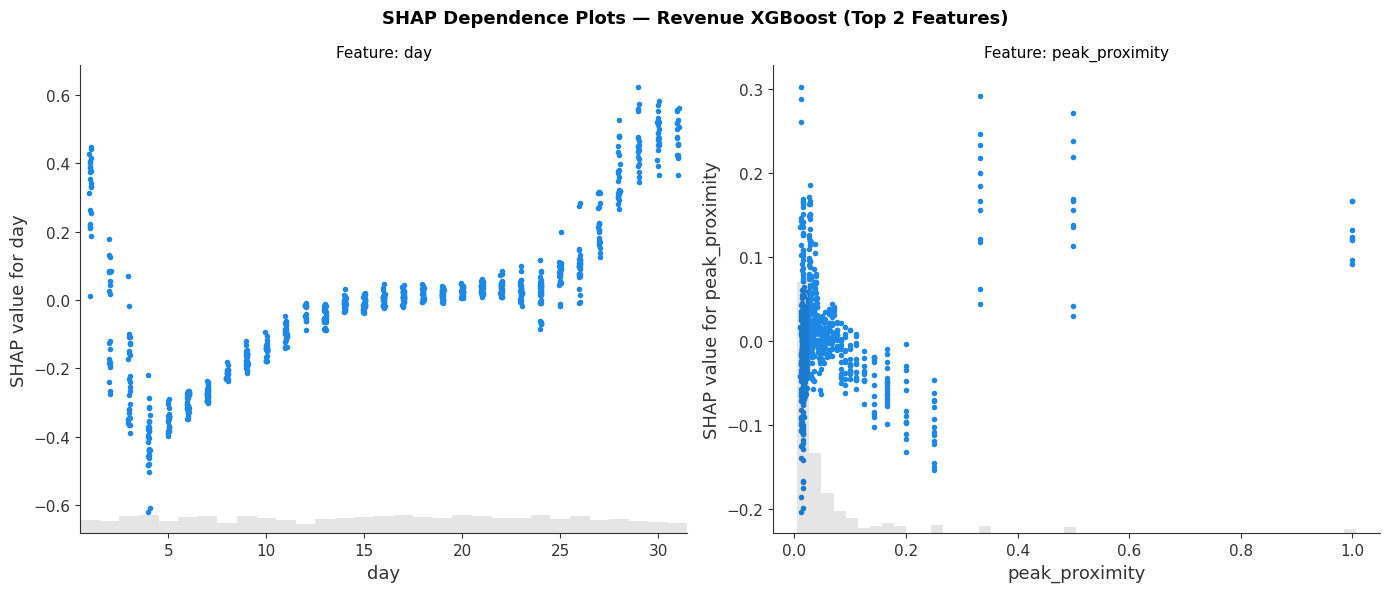

Saved: shap_dependence_revenue.png


In [42]:
# Xác định top 2 features từ Revenue XGBoost
sv_rev_xgb = shap_dict['rev_xgboost']
mean_abs_rev_xgb = np.abs(sv_rev_xgb.values).mean(axis=0)
top2_idx = np.argsort(mean_abs_rev_xgb)[::-1][:2]
top2_features = [STATIC_FEATURES[i] for i in top2_idx]

print(f"Top 2 features (Revenue XGBoost): {top2_features}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("SHAP Dependence Plots — Revenue XGBoost (Top 2 Features)", 
             fontsize=13, fontweight='bold')

for ax, feat in zip(axes, top2_features):
    plt.sca(ax)
    shap.plots.scatter(
        sv_rev_xgb[:, feat],
        show=False,
        ax=ax
    )
    ax.set_title(f'Feature: {feat}', fontsize=11)
    ax.set_xlabel(feat)
    ax.set_ylabel(f'SHAP value for {feat}')

plt.tight_layout()
plt.savefig("shap_dependence_revenue.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_dependence_revenue.png")

## 11. Summary: Feature Ranking Table

Bảng tổng hợp rank của từng feature theo mean |SHAP| trong cả 6 models.

In [43]:
records = []
col_info = [
    ('rev_xgboost',  'Rev_XGB'),
    ('rev_lightgbm', 'Rev_LGB'),
    ('rev_catboost', 'Rev_CAT'),
    ('rat_xgboost',  'Rat_XGB'),
    ('rat_lightgbm', 'Rat_LGB'),
    ('rat_catboost', 'Rat_CAT'),
]

summary = pd.DataFrame(index=STATIC_FEATURES)
for key, col in col_info:
    sv = shap_dict[key]
    mean_abs = np.abs(sv.values).mean(axis=0)
    summary[col] = mean_abs

summary['Mean_All'] = summary.mean(axis=1)
summary = summary.sort_values('Mean_All', ascending=False)

# Rank columns (1 = most important)
rank_cols = [c for _, c in col_info]
summary_rank = summary[rank_cols].rank(ascending=False).astype(int)
summary_rank.columns = [f'Rank_{c}' for c in summary_rank.columns]
summary_rank['Mean_|SHAP|'] = summary['Mean_All'].round(5)

print("=" * 70)
print("FEATURE IMPORTANCE SUMMARY (sorted by Mean |SHAP| across all 6 models)")
print("=" * 70)
print(summary_rank.to_string())

# Highlight top 5
print("\n" + "=" * 70)
print("TOP 5 MOST IMPORTANT FEATURES:")
for i, feat in enumerate(summary.index[:5], 1):
    print(f"  #{i}: {feat:30s}  Mean |SHAP| = {summary.loc[feat, 'Mean_All']:.5f}")

FEATURE IMPORTANCE SUMMARY (sorted by Mean |SHAP| across all 6 models)
                      Rank_Rev_XGB  Rank_Rev_LGB  Rank_Rev_CAT  Rank_Rat_XGB  Rank_Rat_LGB  Rank_Rat_CAT  Mean_|SHAP|
day                              1             1             1             8             9            10      0.07867
year                             3             5             3             2             2             1      0.02975
sale_rank                       10             8            10             1             1             2      0.02883
peak_proximity                   2             2             2             3             3             5      0.02611
days_since_last_sale             6             4             6             5             5             3      0.01446
month_cos                        5             3             4             7             8             9      0.01401
month                            8             6             7             6             7             

## 12. Waterfall Plot — Giải thích dự đoán 1 ngày cụ thể

Chọn bất kỳ ngày nào để xem **từng feature đóng góp bao nhiêu** vào dự đoán của ngày đó.

Note: 2022-01-30 không nằm trong background sample. Dùng index 0 thay thế.


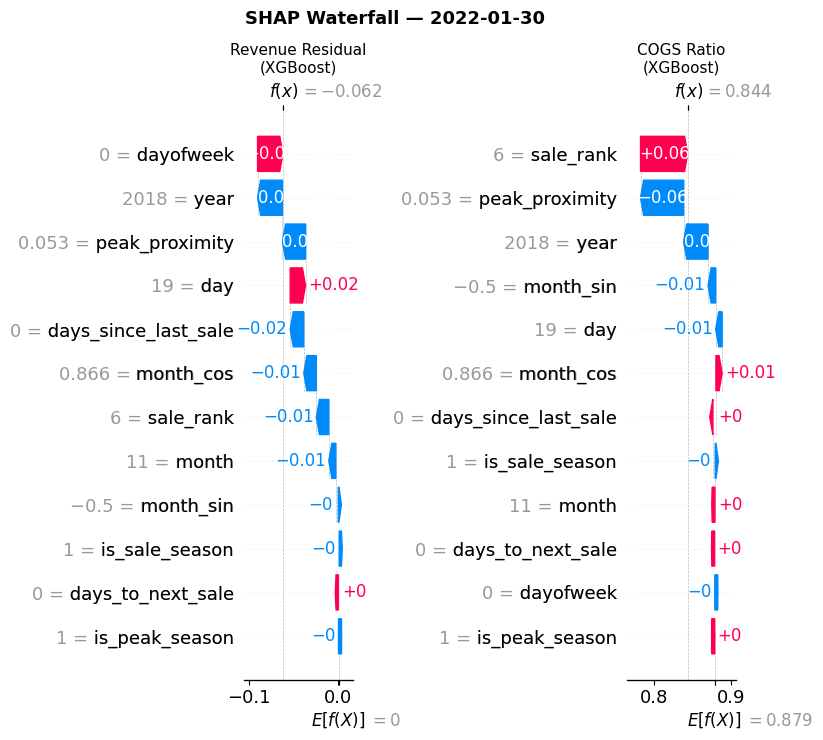

Saved: shap_waterfall_2022-01-30.png


In [44]:
# Chọn ngày muốn explain (thay đổi tùy ý)
EXPLAIN_DATE = '2022-01-30'  # Ví dụ: ngày đầu sale tháng 1 (sale rank #1)

date_mask = df['Date'] == EXPLAIN_DATE
if not date_mask.any():
    print(f"Không tìm thấy {EXPLAIN_DATE} trong training data.")
else:
    explain_idx_in_bg = None
    # Tìm index trong background sample
    date_row = df[date_mask].index[0]
    if date_row in bg_idx:
        explain_idx_in_bg = np.where(bg_idx == date_row)[0][0]
    else:
        # Lấy row gần nhất trong bg
        explain_idx_in_bg = 0
        print(f"Note: {EXPLAIN_DATE} không nằm trong background sample. Dùng index 0 thay thế.")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"SHAP Waterfall — {EXPLAIN_DATE}", fontsize=13, fontweight='bold')

    for ax, (key, label) in zip(axes, [('rev_xgboost', 'Revenue Residual\n(XGBoost)'),
                                        ('rat_xgboost', 'COGS Ratio\n(XGBoost)')]):
        plt.sca(ax)
        shap.plots.waterfall(shap_dict[key][explain_idx_in_bg], max_display=12, show=False)
        ax.set_title(label, fontsize=11)

    plt.tight_layout()
    plt.savefig(f"shap_waterfall_{EXPLAIN_DATE}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: shap_waterfall_{EXPLAIN_DATE}.png")